# Ensemble: Xception + EfficientNetV2B0 + ViT-B16 com Weighted Averaging

**Proposta de Projeto** – CIn/UFPE  
Detecção de Câncer de Pele com Ensemble de Modelos Deep Learning + XAI

## Descrição

Este notebook implementa um **ensemble de três arquiteturas de Transfer Learning**:
- **Xception** – CNN profunda com convoluções separáveis por profundidade (base: artigo Shah et al. 2024)
- **EfficientNetV2B0** – CNN com compound scaling, eficiência superior em parâmetros
- **ViT-B16** – Vision Transformer, mecanismo de self-attention sobre patches de imagem

A combinação é realizada por **Weighted Averaging** das probabilidades de predição,  
com pesos otimizados automaticamente no conjunto de validação.

## Dataset
- **ISIC 2018 – Classificação Binária:** benigno (0) / maligno (1)
- **Treino:** 1440 benignas + 1197 malignas → 10.548 após augmentação 4×
- **Teste:** 360 benignas + 300 malignas (660 total, sem augmentação)
- **Tamanho das imagens:** 224×224 pixels, RGB, normalizado [0, 1]

## Estrutura do Notebook
1. Carregamento e EDA dos dados
2. Pré-processamento e augmentação (igual à reprodução do artigo)
3. Modelo 1 – Xception Transfer Learning
4. Modelo 2 – EfficientNetV2B0 Transfer Learning
5. Modelo 3 – ViT-B16 Transfer Learning
6. Comparação dos modelos individuais
7. Ensemble com Weighted Averaging (pesos otimizados)
8. XAI: Grad-CAM, LIME, Occlusion Sensitivity
9. Resumo e conclusões

## 0. Instalação de Dependências

In [1]:
!pip install vit-keras tf-keras opencv-python-headless lime tf-keras-vis scipy --quiet

## 1. Importação de Bibliotecas

In [2]:
# ── Bibliotecas padrão ──────────────────────────────────────────────────────
import os
import glob
import warnings
import random
warnings.filterwarnings('ignore')

# TF_KERAS=1 força vit_keras a usar tf.keras (Keras 2 API) em vez do Keras 3
os.environ['TF_KERAS'] = '1'

# ── Dados e visualização ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image, ImageFilter

# ── Otimização (pesos do ensemble) ──────────────────────────────────────────
from scipy.optimize import minimize

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import Xception, EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

# ── XAI ────────────────────────────────────────────────────────────────────
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ── ViT (vit-keras) ─────────────────────────────────────────────────────────
# vit_keras usa Keras 2 / tf.keras; TF_KERAS=1 (definido acima) garante compatibilidade
try:
    from vit_keras import vit as vit_module
    VIT_AVAILABLE = True
    print('vit_keras carregado com sucesso.')
except Exception as e:
    VIT_AVAILABLE = False
    print(f'vit_keras indisponível: {e}')
    print('Execute: pip install vit-keras tf-keras opencv-python-headless')

# ── Configurações globais ───────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')
print(f'GPUs:       {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1779117140.701333 2093455 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779117145.954103 2093455 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779117161.945908 2093455 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


vit_keras carregado com sucesso.
TensorFlow: 2.21.0
Keras:      3.12.1
GPUs:       []


E0000 00:00:1779117167.600794 2093455 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Carregamento e Exploração dos Dados (EDA)

Mesma estrutura da reprodução do artigo: leitura dos caminhos via `glob`,
criação de DataFrames com `path` e `label`.

In [3]:
# ── Caminhos base ───────────────────────────────────────────────────────────
DATA_DIR   = '/home/lmelo/others/Skin_Cancer_TransferLearning_XAI/data/'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
TEST_DIR   = os.path.join(DATA_DIR, 'test')
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

def collect_paths(base_dir):
    """Retorna DataFrame com colunas 'path' e 'label'."""
    records = []
    for label in ['benign', 'malignant']:
        for p in glob.glob(os.path.join(base_dir, label, '*.jpg')):
            records.append({'path': p, 'label': label})
    return pd.DataFrame(records)

df_train = collect_paths(TRAIN_DIR)
df_test  = collect_paths(TEST_DIR)

print('=== Treino ===')
print(df_train['label'].value_counts())
print(f'Total: {len(df_train)} imagens\n')

print('=== Teste ===')
print(df_test['label'].value_counts())
print(f'Total: {len(df_test)} imagens')

=== Treino ===
label
benign       1440
malignant    1197
Name: count, dtype: int64
Total: 2637 imagens

=== Teste ===
label
benign       360
malignant    300
Name: count, dtype: int64
Total: 660 imagens


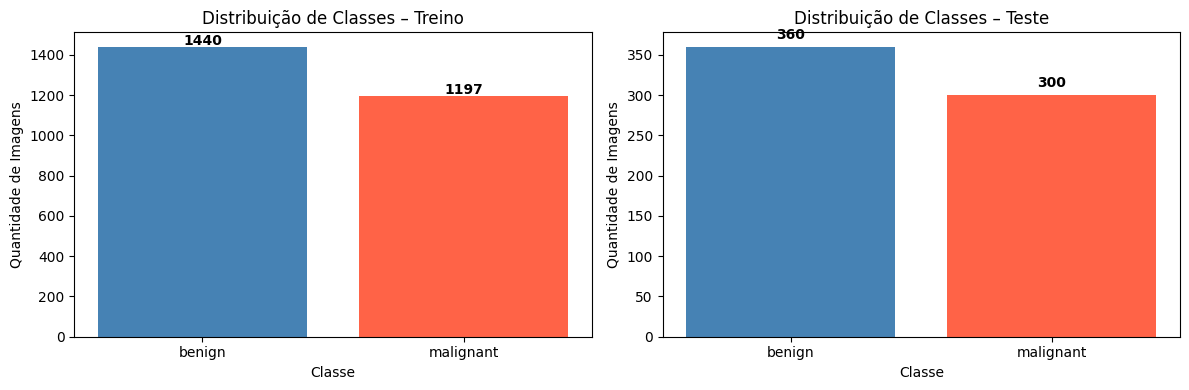

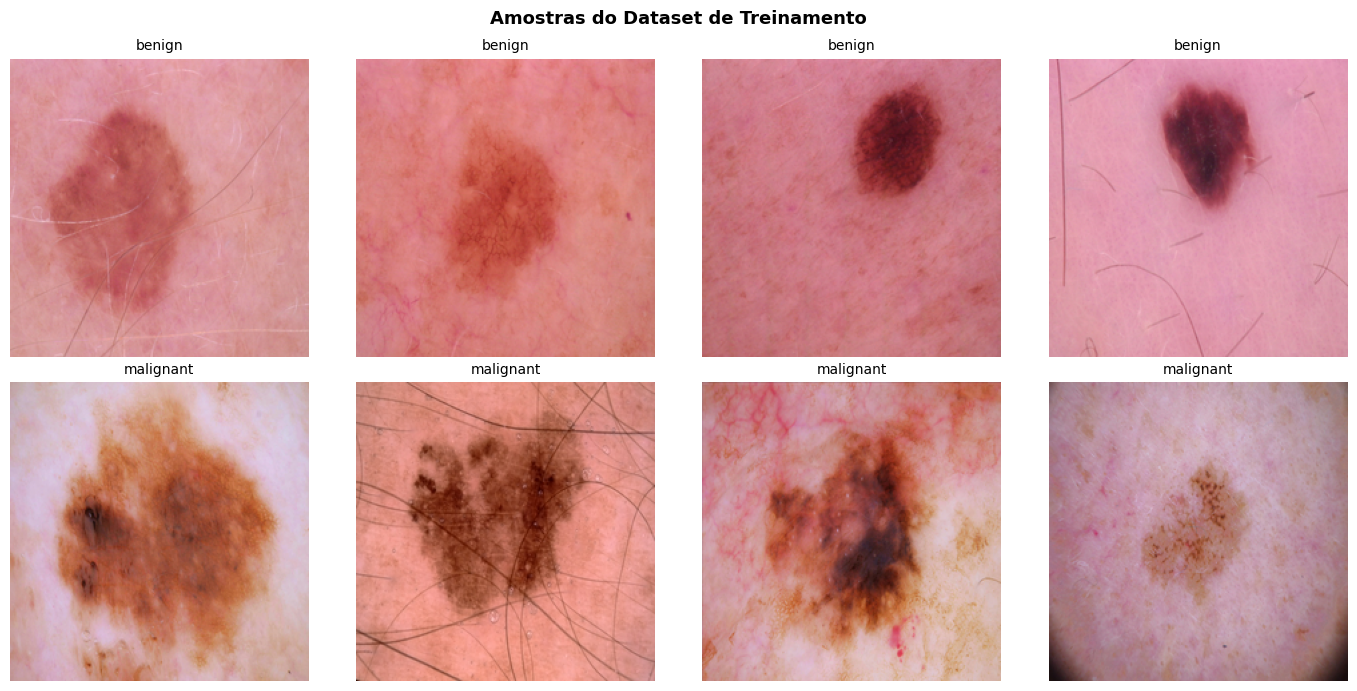

In [4]:
# ── Distribuição de classes ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, titulo) in zip(axes, [(df_train, 'Treino'), (df_test, 'Teste')]):
    contagens = df['label'].value_counts()
    ax.bar(contagens.index, contagens.values, color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuição de Classes – {titulo}')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Quantidade de Imagens')
    for i, v in enumerate(contagens.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Amostras do dataset ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, label in enumerate(['benign', 'malignant']):
    amostras = df_train[df_train['label'] == label].sample(4, random_state=SEED)
    for j, (_, row) in enumerate(amostras.iterrows()):
        img = Image.open(row['path']).resize(IMG_SIZE)
        axes[i, j].imshow(img)
        axes[i, j].set_title(label, fontsize=10)
        axes[i, j].axis('off')
plt.suptitle('Amostras do Dataset de Treinamento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Pré-processamento e Augmentação

Conforme a Seção 3.1.3 do artigo (Shah et al. 2024), a augmentação é aplicada
**apenas ao conjunto de treino** e inclui 3 operações por imagem original:

| Técnica | Parâmetros |
|---------|------------|
| Rotação aleatória | –180° a +180° |
| Gaussian Blur | σ = 2 |
| Sharpening | amount=2, radius=1, threshold=0 |

Fator de multiplicação: **4×** (original + 3 augmentações)
→ 2.637 × 4 = **10.548 imagens** de treino.

In [5]:
def load_image(path, size=IMG_SIZE):
    """Carrega, redimensiona e normaliza para [0, 1]."""
    img = Image.open(path).convert('RGB').resize(size)
    return np.array(img, dtype=np.float32) / 255.0

def augment_rotation(img_array):
    angle = np.random.uniform(-180, 180)
    pil   = Image.fromarray((img_array * 255).astype(np.uint8))
    return np.array(pil.rotate(angle, resample=Image.BILINEAR), dtype=np.float32) / 255.0

def augment_gaussian_blur(img_array, sigma=2):
    pil = Image.fromarray((img_array * 255).astype(np.uint8))
    return np.array(pil.filter(ImageFilter.GaussianBlur(radius=sigma)), dtype=np.float32) / 255.0

def augment_sharpen(img_array, amount=2, radius=1):
    pil = Image.fromarray((img_array * 255).astype(np.uint8))
    sharpened = pil.filter(ImageFilter.UnsharpMask(radius=radius, percent=int(amount*100), threshold=0))
    return np.array(sharpened, dtype=np.float32) / 255.0

print('Funções de augmentação definidas.')

Funções de augmentação definidas.


In [6]:
def build_augmented_dataset(df):
    """Gera dataset com original + 3 augmentações por imagem."""
    X_list, y_list = [], []
    label_map = {'benign': 0, 'malignant': 1}
    print(f'Processando {len(df)} imagens originais...')
    for idx, row in df.iterrows():
        img = load_image(row['path'])
        lbl = label_map[row['label']]
        X_list += [img, augment_rotation(img), augment_gaussian_blur(img), augment_sharpen(img)]
        y_list += [lbl, lbl, lbl, lbl]
        if (idx + 1) % 500 == 0:
            print(f'  {idx + 1}/{len(df)} processadas...')
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    print(f'Dataset aumentado: {X.shape[0]} imagens ({np.sum(y==0)} benignas, {np.sum(y==1)} malignas)')
    return X, y

def build_test_dataset(df):
    label_map = {'benign': 0, 'malignant': 1}
    X = np.array([load_image(p) for p in df['path']], dtype=np.float32)
    y = np.array([label_map[l] for l in df['label']], dtype=np.int32)
    print(f'Teste: {X.shape[0]} imagens ({np.sum(y==0)} benignas, {np.sum(y==1)} malignas)')
    return X, y

print('Carregando imagens de teste...')
X_test, y_test = build_test_dataset(df_test)

print('\nCriando dataset de treino com augmentação (pode levar alguns minutos)...')
X_train_aug, y_train_aug = build_augmented_dataset(df_train)

Carregando imagens de teste...
Teste: 660 imagens (360 benignas, 300 malignas)

Criando dataset de treino com augmentação (pode levar alguns minutos)...
Processando 2637 imagens originais...
  500/2637 processadas...
  1000/2637 processadas...
  1500/2637 processadas...
  2000/2637 processadas...
  2500/2637 processadas...
Dataset aumentado: 10548 imagens (5760 benignas, 4788 malignas)


In [7]:
# ── Divisão 70% treino / 30% validação (conforme o artigo) ──────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_aug, y_train_aug,
    test_size=0.30, random_state=SEED, stratify=y_train_aug
)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

# ── One-hot encoding ─────────────────────────────────────────────────────────
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   num_classes=2)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=2)

# ── tf.data.Dataset ──────────────────────────────────────────────────────────
ds_train = (tf.data.Dataset.from_tensor_slices((X_train, y_train_oh))
            .shuffle(buffer_size=2000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

ds_val   = (tf.data.Dataset.from_tensor_slices((X_val, y_val_oh))
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

ds_test  = (tf.data.Dataset.from_tensor_slices((X_test, y_test_oh))
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

print('\nDatasets TensorFlow criados com sucesso.')

Treino:    7383 amostras
Validação: 3165 amostras
Teste:     660 amostras


W0000 00:00:1779117349.171447 2093455 cpu_allocator_impl.cc:82] Allocation of 4445392896 exceeds 10% of free system memory.



Datasets TensorFlow criados com sucesso.


W0000 00:00:1779117360.715529 2093455 cpu_allocator_impl.cc:82] Allocation of 1905684480 exceeds 10% of free system memory.


## Função Auxiliar de Métricas

Calcula Acurácia, Sensibilidade, Especificidade, Precisão, F1 e AUC,
e plota Matriz de Confusão + Curva ROC.

In [8]:
def compute_metrics(y_true, y_pred, y_prob, label='Modelo'):
    """Calcula métricas e plota CM + ROC."""
    acc  = accuracy_score(y_true, y_pred)
    cm_m = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm_m.ravel()
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0.0

    print(f'\n=== Métricas – {label} ===')
    print(f'  Acurácia:       {acc*100:.2f}%')
    print(f'  Sensibilidade:  {sens*100:.2f}%')
    print(f'  Especificidade: {spec*100:.2f}%')
    print(f'  Precisão:       {prec*100:.2f}%')
    print(f'  F1-Score:       {f1*100:.2f}%')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_m, display_labels=['Benigno', 'Maligno'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Matriz de Confusão – {label}')

    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Taxa de Falso Positivo')
    axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
    axes[1].set_title(f'Curva ROC – {label}')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    return {'label': label, 'acuracia': acc, 'sensibilidade': sens,
            'especificidade': spec, 'precisao': prec, 'f1': f1, 'auc': roc_auc}


def plot_learning_curves(history, titulo):
    """Plota curvas de acurácia e perda."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Treino',    marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Validação', marker='s')
    axes[0].set_title(f'Acurácia – {titulo}')
    axes[0].set_xlabel('Épocas')
    axes[0].set_ylabel('Acurácia')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'],     label='Treino',    marker='o')
    axes[1].plot(history.history['val_loss'], label='Validação', marker='s')
    axes[1].set_title(f'Perda – {titulo}')
    axes[1].set_xlabel('Épocas')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

# Dicionário global de resultados
resultados = {}
print('Função de métricas definida.')

Função de métricas definida.


## 4. Modelo 1 – Xception Transfer Learning

Idêntico ao Experimento 1 da reprodução do artigo (Shah et al. 2024):
- Base: **Xception pré-treinado no ImageNet**, 100% congelado
- Cabeça: GlobalAveragePooling2D → Dense(512, ReLU) → Dense(256, ReLU) → Dense(2, Softmax)
- Treinamento: EarlyStopping (patience=5) sobre val_loss

In [9]:
# ── Construção ───────────────────────────────────────────────────────────────
base_xception = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_xception.trainable = False

inputs_x = keras.Input(shape=(224, 224, 3))
x        = base_xception(inputs_x, training=False)
x        = layers.GlobalAveragePooling2D()(x)
x        = layers.Dense(512, activation='relu')(x)
x        = layers.Dense(256, activation='relu')(x)
outputs_x = layers.Dense(2, activation='softmax')(x)

model_xception = Model(inputs_x, outputs_x, name='Xception_TL')
model_xception.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable     = sum(tf.size(w).numpy() for w in model_xception.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model_xception.non_trainable_weights)
print(f'Parâmetros treináveis:     {trainable:,}')
print(f'Parâmetros não treináveis: {non_trainable:,}')
model_xception.summary()

Parâmetros treináveis:     1,180,930
Parâmetros não treináveis: 20,861,480


Model: "Xception_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,042,410 (84.09 MB)

 Trainable params: 1,180,930 (4.50 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [10]:
callbacks_xception = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history_xception = model_xception.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    callbacks=callbacks_xception,
    verbose=1
)

print('\nTreinamento do Xception concluído!')

Epoch 1/10


W0000 00:00:1779117365.137293 2093455 cpu_allocator_impl.cc:82] Allocation of 4445392896 exceeds 10% of free system memory.


231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7109 - loss: 0.5631

W0000 00:00:1779117844.691834 2093455 cpu_allocator_impl.cc:82] Allocation of 1905684480 exceeds 10% of free system memory.


231/231 ━━━━━━━━━━━━━━━━━━━━ 668s 3s/step - accuracy: 0.7777 - loss: 0.4538 - val_accuracy: 0.8139 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 642s 3s/step - accuracy: 0.8505 - loss: 0.3335 - val_accuracy: 0.8240 - val_loss: 0.3707 - learning_rate: 0.0010
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 619s 3s/step - accuracy: 0.8644 - loss: 0.2940 - val_accuracy: 0.8509 - val_loss: 0.3288 - learning_rate: 0.0010
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 662s 3s/step - accuracy: 0.8769 - loss: 0.2675 - val_accuracy: 0.8566 - val_loss: 0.3164 - learning_rate: 0.0010
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 640s 3s/step - accuracy: 0.8988 - loss: 0.2252 - val_accuracy: 0.8689 - val_loss: 0.3173 - learning_rate: 0.0010
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 695s 3s/step - accuracy: 0.9091 - loss: 0.2030 - val_accuracy: 0.8648 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9348 - loss: 0.1668
Epoch 7:

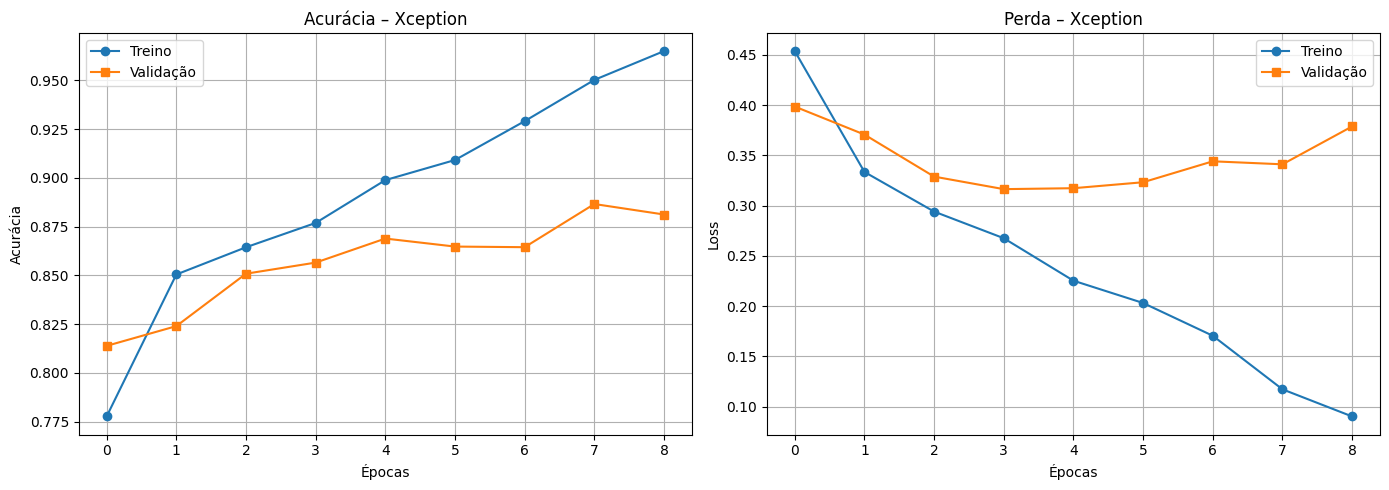

In [11]:
plot_learning_curves(history_xception, 'Xception')


=== Métricas – Xception TL ===
  Acurácia:       82.27%
  Sensibilidade:  84.33%
  Especificidade: 80.56%
  Precisão:       78.33%
  F1-Score:       81.22%


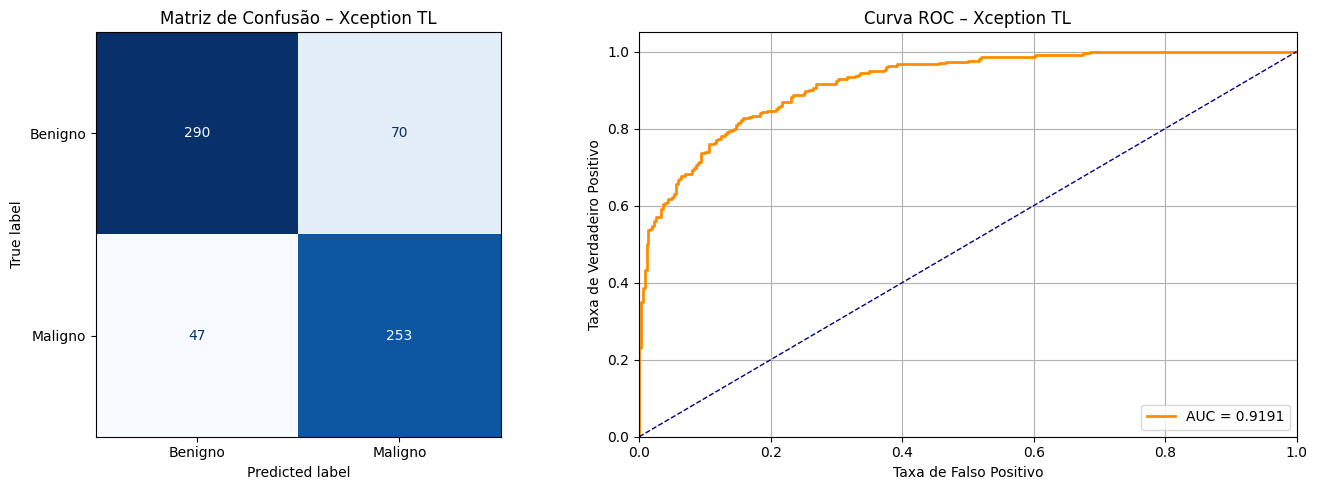

In [12]:
y_prob_xception = model_xception.predict(X_test, verbose=0)
y_pred_xception = np.argmax(y_prob_xception, axis=1)

resultados['Xception'] = compute_metrics(
    y_test, y_pred_xception, y_prob_xception, label='Xception TL'
)

## 5. Modelo 2 – EfficientNetV2B0 Transfer Learning

- Base: **EfficientNetV2B0 pré-treinado no ImageNet**, 100% congelado
- Preprocessing: Rescaling([0,1]→[0,255]) antes do backbone (EfficientNetV2 espera [0,255])
- Cabeça: GlobalAveragePooling2D → Dropout(0.2) → Dense(256, ReLU) → Dense(128, ReLU) → Dense(2, Softmax)
- Treinamento: EarlyStopping (patience=5) sobre val_loss

In [13]:
# ── Construção ───────────────────────────────────────────────────────────────
# include_preprocessing=True: o backbone aplica normalização interna a partir de [0,255]
# Adicionamos Rescaling(255.) para converter nossas imagens [0,1] para [0,255]
base_effnet = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    include_preprocessing=True,
    input_shape=(224, 224, 3)
)
base_effnet.trainable = False

inputs_e  = keras.Input(shape=(224, 224, 3))
x         = layers.Rescaling(255.0)(inputs_e)   # [0,1] → [0,255]
x         = base_effnet(x, training=False)
x         = layers.GlobalAveragePooling2D()(x)
x         = layers.Dropout(0.2)(x)
x         = layers.Dense(256, activation='relu')(x)
x         = layers.Dense(128, activation='relu')(x)
outputs_e = layers.Dense(2, activation='softmax')(x)

model_effnet = Model(inputs_e, outputs_e, name='EfficientNetV2B0_TL')
model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable     = sum(tf.size(w).numpy() for w in model_effnet.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model_effnet.non_trainable_weights)
print(f'Parâmetros treináveis:     {trainable:,}')
print(f'Parâmetros não treináveis: {non_trainable:,}')
model_effnet.summary()

Parâmetros treináveis:     361,090
Parâmetros não treináveis: 5,919,312


Model: "EfficientNetV2B0_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,280,402 (23.96 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [14]:
callbacks_effnet = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history_effnet = model_effnet.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    callbacks=callbacks_effnet,
    verbose=1
)

print('\nTreinamento do EfficientNetV2B0 concluído!')

Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 204s 846ms/step - accuracy: 0.8209 - loss: 0.3661 - val_accuracy: 0.8452 - val_loss: 0.3183 - learning_rate: 0.0010
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 183s 794ms/step - accuracy: 0.8632 - loss: 0.2937 - val_accuracy: 0.8490 - val_loss: 0.3162 - learning_rate: 0.0010
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 183s 793ms/step - accuracy: 0.8769 - loss: 0.2699 - val_accuracy: 0.8711 - val_loss: 0.2759 - learning_rate: 0.0010
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 193s 838ms/step - accuracy: 0.8799 - loss: 0.2594 - val_accuracy: 0.8752 - val_loss: 0.2792 - learning_rate: 0.0010
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 183s 794ms/step - accuracy: 0.8903 - loss: 0.2425 - val_accuracy: 0.8790 - val_loss: 0.2687 - learning_rate: 0.0010
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 193s 837ms/step - accuracy: 0.8969 - loss: 0.2268 - val_accuracy: 0.8796 - val_loss: 0.2733 - learning_rate: 0.0010
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 199s 862ms/step - accura

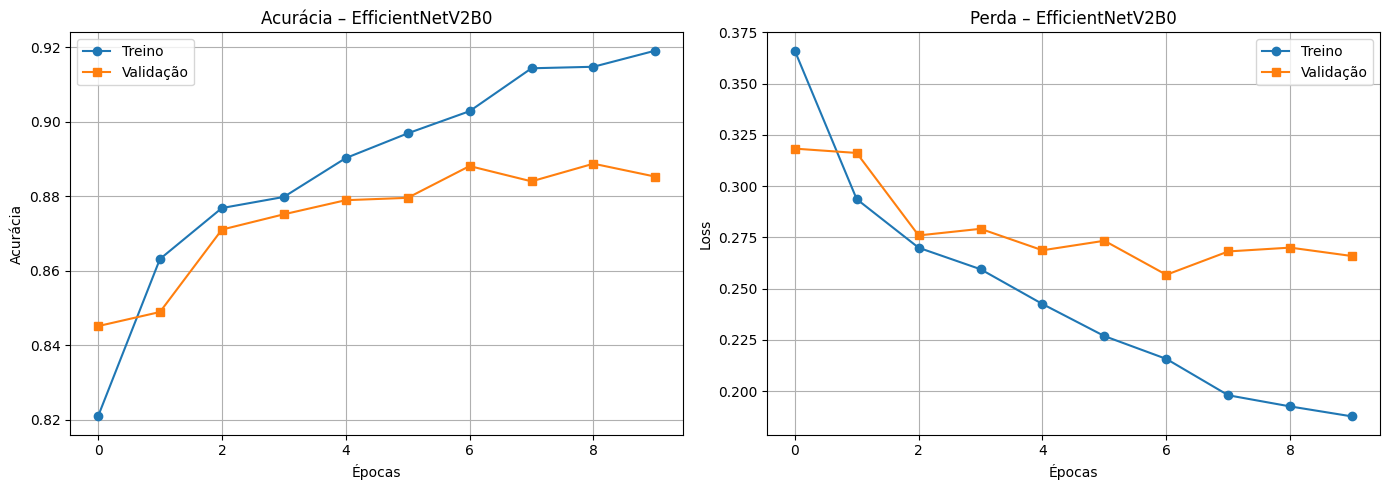

In [15]:
plot_learning_curves(history_effnet, 'EfficientNetV2B0')


=== Métricas – EfficientNetV2B0 TL ===
  Acurácia:       87.42%
  Sensibilidade:  84.33%
  Especificidade: 90.00%
  Precisão:       87.54%
  F1-Score:       85.91%


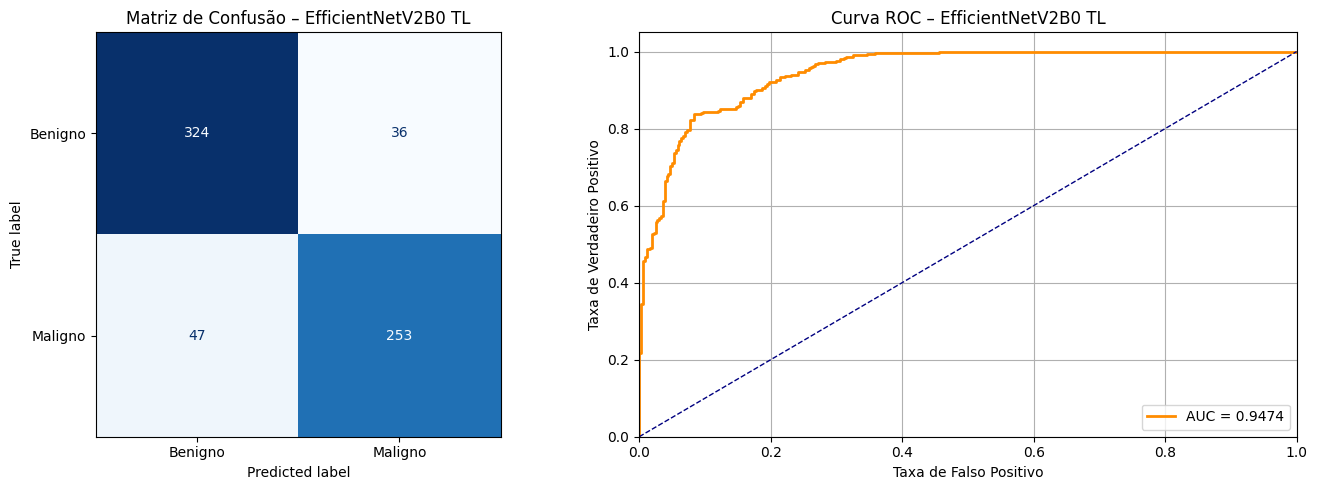

In [16]:
y_prob_effnet = model_effnet.predict(X_test, verbose=0)
y_pred_effnet = np.argmax(y_prob_effnet, axis=1)

resultados['EfficientNetV2B0'] = compute_metrics(
    y_test, y_pred_effnet, y_prob_effnet, label='EfficientNetV2B0 TL'
)

## 6. Modelo 3 – ViT-B16 Transfer Learning

- Base: **ViT-B16 pré-treinado no ImageNet** (via `vit_keras`), 100% congelado
- Arquitetura: 12 blocos transformer, 12 heads de atenção, dim=768, patches 16×16
- Cabeça: Dropout(0.2) → Dense(128, ReLU) → Dense(2, Softmax)
- Treinamento: EarlyStopping (patience=5) sobre val_loss

> **Nota de compatibilidade:** `vit_keras` foi projetado para Keras 2.  
> Se ocorrerem erros com Keras 3, instale `tf-keras` e reinicie o kernel com  
> `os.environ['TF_KERAS'] = '1'` definido antes dos imports de TF.

In [17]:
# ── Recuperação in-place: instala cv2 + tf-keras e reimporta se necessário ──
if not VIT_AVAILABLE:
    import subprocess, sys
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install',
         'opencv-python-headless', 'tf-keras', '--quiet'],
        check=True
    )
    os.environ['TF_KERAS'] = '1'
    try:
        from vit_keras import vit as vit_module
        VIT_AVAILABLE = True
        print('vit_keras carregado com sucesso após instalação de dependências.')
    except Exception as e:
        raise RuntimeError(f'Falha ao carregar vit_keras mesmo após instalação: {e}')

# ── Carregar backbone ViT-B16 pré-treinado ───────────────────────────────────
# include_top=False remove a cabeça de classificação original (1000 classes)
# A saída é um vetor de 768 dimensões (representação CLS token)
vit_base = vit_module.vit_b16(
    image_size=224,
    activation='sigmoid',
    pretrained=True,
    include_top=False,
    pretrained_top=False,
    classes=2
)

# Congelar todas as camadas do backbone
for layer in vit_base.layers:
    layer.trainable = False

# ── Cabeça de classificação ──────────────────────────────────────────────────
inputs_v  = keras.Input(shape=(224, 224, 3))
x         = vit_base(inputs_v)
x         = layers.Dropout(0.2)(x)
x         = layers.Dense(128, activation='relu')(x)
outputs_v = layers.Dense(2, activation='softmax')(x)

model_vit = Model(inputs_v, outputs_v, name='ViT_B16_TL')
model_vit.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable     = sum(tf.size(w).numpy() for w in model_vit.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model_vit.non_trainable_weights)
print(f'Parâmetros treináveis:     {trainable:,}')
print(f'Parâmetros não treináveis: {non_trainable:,}')
model_vit.summary()

Parâmetros treináveis:     98,690
Parâmetros não treináveis: 85,798,656


Model: "ViT_B16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vit-b16 (Functional)            │ (None, 768)            │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,897,346 (327.67 MB)

 Trainable params: 98,690 (385.51 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

In [18]:
callbacks_vit = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history_vit = model_vit.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    callbacks=callbacks_vit,
    verbose=1
)

print('\nTreinamento do ViT-B16 concluído!')

Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 3102s 13s/step - accuracy: 0.8208 - loss: 0.3852 - val_accuracy: 0.8566 - val_loss: 0.3180 - learning_rate: 0.0010
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 3263s 14s/step - accuracy: 0.8692 - loss: 0.2915 - val_accuracy: 0.8654 - val_loss: 0.2848 - learning_rate: 0.0010
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 3534s 15s/step - accuracy: 0.8746 - loss: 0.2702 - val_accuracy: 0.8777 - val_loss: 0.2655 - learning_rate: 0.0010
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 3512s 15s/step - accuracy: 0.8851 - loss: 0.2543 - val_accuracy: 0.8831 - val_loss: 0.2606 - learning_rate: 0.0010
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 3304s 14s/step - accuracy: 0.8937 - loss: 0.2373 - val_accuracy: 0.8825 - val_loss: 0.2565 - learning_rate: 0.0010
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 3077s 13s/step - accuracy: 0.8965 - loss: 0.2231 - val_accuracy: 0.8882 - val_loss: 0.2540 - learning_rate: 0.0010
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 3108s 13s/step - accuracy: 0.9

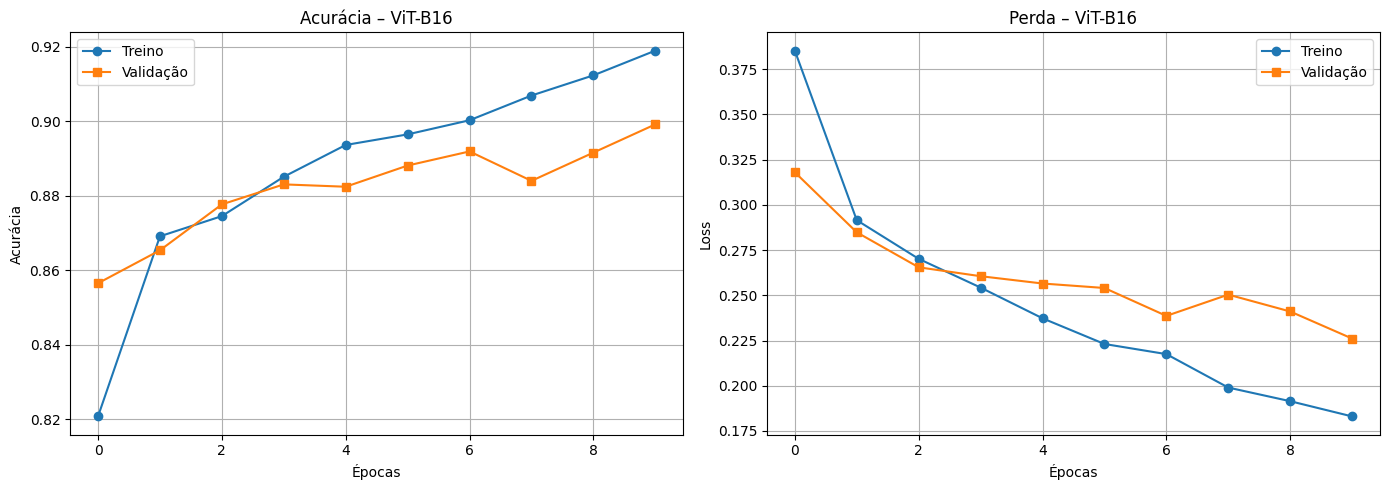

In [19]:
plot_learning_curves(history_vit, 'ViT-B16')


=== Métricas – ViT-B16 TL ===
  Acurácia:       88.03%
  Sensibilidade:  91.33%
  Especificidade: 85.28%
  Precisão:       83.79%
  F1-Score:       87.40%


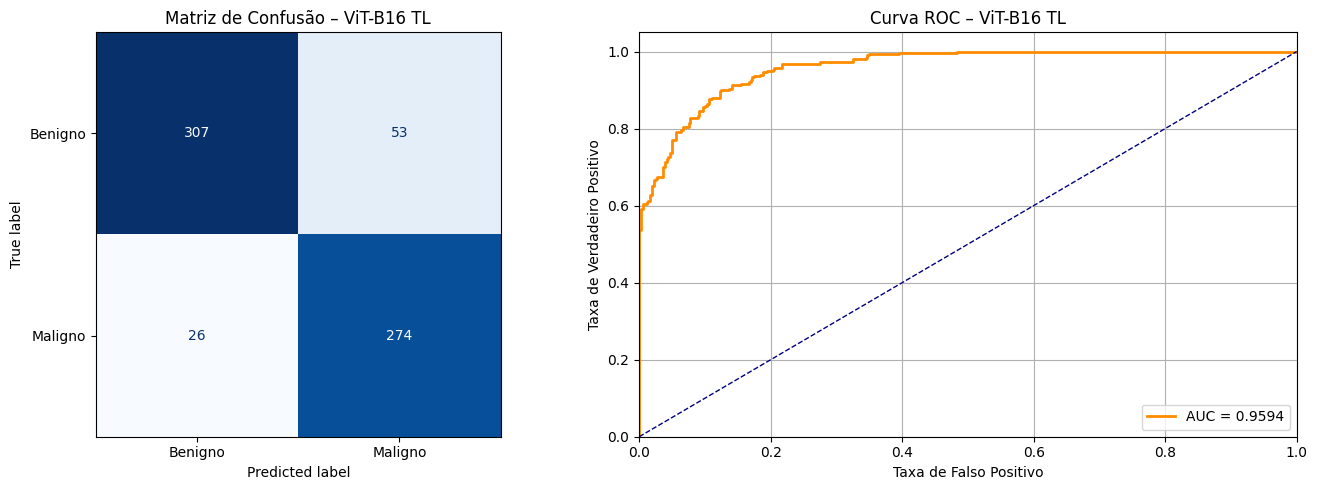

In [20]:
y_prob_vit = model_vit.predict(X_test, verbose=0)
y_pred_vit = np.argmax(y_prob_vit, axis=1)

resultados['ViT-B16'] = compute_metrics(
    y_test, y_pred_vit, y_prob_vit, label='ViT-B16 TL'
)

## 7. Comparação dos Modelos Individuais

Antes de combinar os modelos no ensemble, comparamos o desempenho individual
de cada arquitetura no conjunto de teste.

=== Comparação – Modelos Individuais ===
             Modelo Acurácia (%) Sensibilidade (%) Especif. (%) Precisão (%) F1-Score (%)    AUC
        Xception TL        82.27             84.33        80.56        78.33        81.22 0.9191
EfficientNetV2B0 TL        87.42             84.33        90.00        87.54        85.91 0.9474
         ViT-B16 TL        88.03             91.33        85.28        83.79        87.40 0.9594


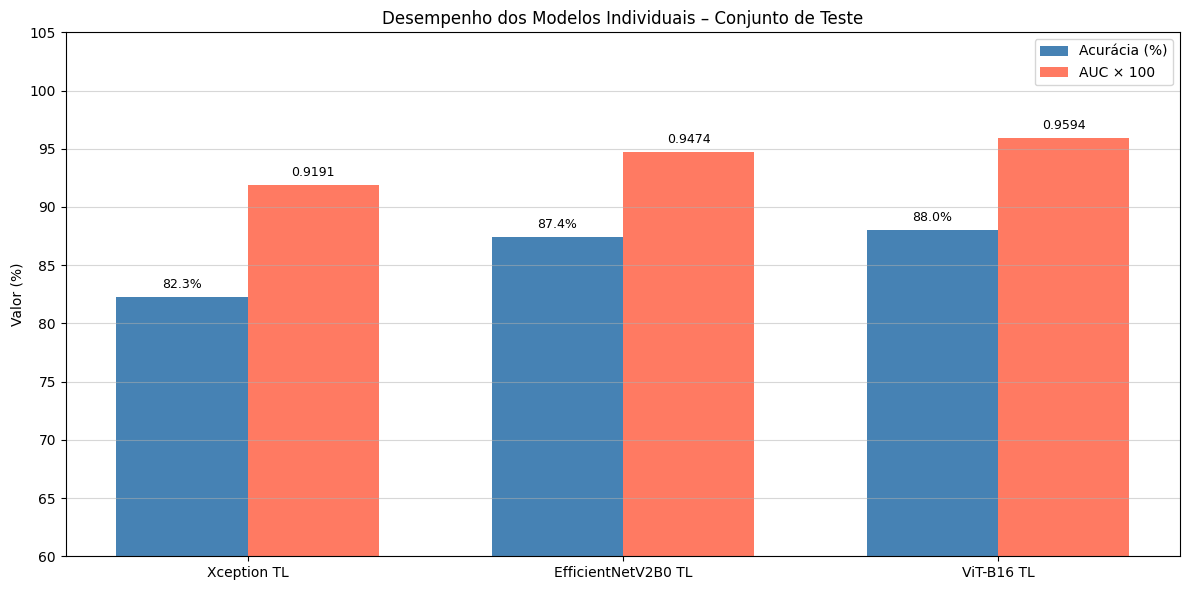

In [21]:
# ── Tabela comparativa ────────────────────────────────────────────────────────
rows_ind = []
for key, res in resultados.items():
    rows_ind.append({
        'Modelo':            res['label'],
        'Acurácia (%)':      f"{res['acuracia']*100:.2f}",
        'Sensibilidade (%)': f"{res['sensibilidade']*100:.2f}",
        'Especif. (%)':      f"{res['especificidade']*100:.2f}",
        'Precisão (%)':      f"{res['precisao']*100:.2f}",
        'F1-Score (%)':      f"{res['f1']*100:.2f}",
        'AUC':               f"{res['auc']:.4f}",
    })

df_ind = pd.DataFrame(rows_ind)
print('=== Comparação – Modelos Individuais ===')
print(df_ind.to_string(index=False))

# ── Gráfico de barras comparativo ────────────────────────────────────────────
nomes     = [r['Modelo'] for r in rows_ind]
acuracias = [float(r['Acurácia (%)']) for r in rows_ind]
aucs      = [float(r['AUC']) * 100 for r in rows_ind]

x_pos = np.arange(len(nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x_pos - width/2, acuracias, width, label='Acurácia (%)', color='steelblue')
bars2 = ax.bar(x_pos + width/2, aucs,      width, label='AUC × 100',    color='tomato', alpha=0.85)

ax.set_ylabel('Valor (%)')
ax.set_title('Desempenho dos Modelos Individuais – Conjunto de Teste')
ax.set_xticks(x_pos)
ax.set_xticklabels(nomes)
ax.legend()
ax.set_ylim([60, 105])
ax.grid(axis='y', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()/100:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Ensemble com Weighted Averaging

### Estratégia

A predição final do ensemble é a **média ponderada** das probabilidades de cada modelo:

$$P_{\text{ensemble}}(x) = w_1 \cdot P_{\text{Xception}}(x) + w_2 \cdot P_{\text{EfficientNet}}(x) + w_3 \cdot P_{\text{ViT}}(x)$$

com $w_1 + w_2 + w_3 = 1$ e $w_i \geq 0$.

### Otimização dos Pesos

Os pesos são otimizados **no conjunto de validação** para maximizar a acurácia,
usando o método SLSQP do `scipy.optimize.minimize` (minimização de $-\text{acurácia}$).
Isso garante que o ensemble aprende a combinação ideal sem usar dados de teste.

In [22]:
# ── Probabilidades de cada modelo no conjunto de VALIDAÇÃO ───────────────────
# Usadas exclusivamente para otimizar os pesos – dados de teste NÃO são usados aqui
print('Calculando probabilidades de validação...')
y_val_prob_xception = model_xception.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
y_val_prob_effnet   = model_effnet.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
y_val_prob_vit      = model_vit.predict(X_val, batch_size=BATCH_SIZE, verbose=0)

print(f'Shape das probabilidades de validação: {y_val_prob_xception.shape}')
print('Probabilidades de validação calculadas.')

Calculando probabilidades de validação...


W0000 00:00:1779157650.672118 2093455 cpu_allocator_impl.cc:82] Allocation of 1905684480 exceeds 10% of free system memory.


Shape das probabilidades de validação: (3165, 2)
Probabilidades de validação calculadas.


=== Pesos Otimizados (validação) ===
  Xception:         0.3333 (33.3%)
  EfficientNetV2B0: 0.3333 (33.3%)
  ViT-B16:          0.3333 (33.3%)
  Acurácia validação (ensemble otimizado): 91.06%
  Acurácia validação (pesos iguais 1/3):   91.06%


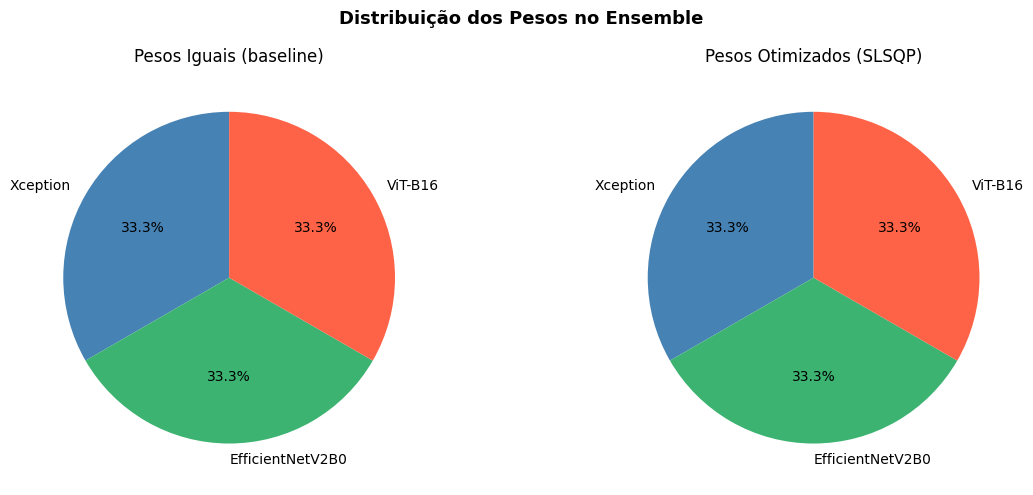

In [23]:
# ── Função de ensemble ────────────────────────────────────────────────────────
def ensemble_predict(probs_list, weights):
    """Média ponderada das probabilidades; normaliza os pesos para somar 1."""
    w = np.array(weights, dtype=np.float64)
    w = w / w.sum()
    return sum(wi * pi for wi, pi in zip(w, probs_list))

# ── Otimização via SLSQP (scipy.optimize) ────────────────────────────────────
val_probs = [y_val_prob_xception, y_val_prob_effnet, y_val_prob_vit]

def neg_accuracy(weights):
    preds = ensemble_predict(val_probs, weights)
    return -accuracy_score(y_val, np.argmax(preds, axis=1))

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
bounds      = [(0.0, 1.0)] * 3
x0          = [1/3, 1/3, 1/3]

result = minimize(neg_accuracy, x0, method='SLSQP', bounds=bounds, constraints=constraints)
opt_weights = result.x / result.x.sum()

print('=== Pesos Otimizados (validação) ===')
print(f'  Xception:         {opt_weights[0]:.4f} ({opt_weights[0]*100:.1f}%)')
print(f'  EfficientNetV2B0: {opt_weights[1]:.4f} ({opt_weights[1]*100:.1f}%)')
print(f'  ViT-B16:          {opt_weights[2]:.4f} ({opt_weights[2]*100:.1f}%)')
print(f'  Acurácia validação (ensemble otimizado): {-result.fun*100:.2f}%')

# ── Comparação: pesos iguais vs. otimizados ──────────────────────────────────
preds_equal = ensemble_predict(val_probs, [1/3, 1/3, 1/3])
acc_equal   = accuracy_score(y_val, np.argmax(preds_equal, axis=1))
print(f'  Acurácia validação (pesos iguais 1/3):   {acc_equal*100:.2f}%')

# ── Visualização dos pesos ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos   = ['Xception', 'EfficientNetV2B0', 'ViT-B16']
cores     = ['steelblue', 'mediumseagreen', 'tomato']

axes[0].pie([1/3, 1/3, 1/3], labels=modelos, colors=cores, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Pesos Iguais (baseline)')

axes[1].pie(opt_weights, labels=modelos, colors=cores, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Pesos Otimizados (SLSQP)')

plt.suptitle('Distribuição dos Pesos no Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Calculando probabilidades de teste...

=== Métricas – Ensemble – Pesos Iguais ===
  Acurácia:       88.33%
  Sensibilidade:  89.67%
  Especificidade: 87.22%
  Precisão:       85.40%
  F1-Score:       87.48%


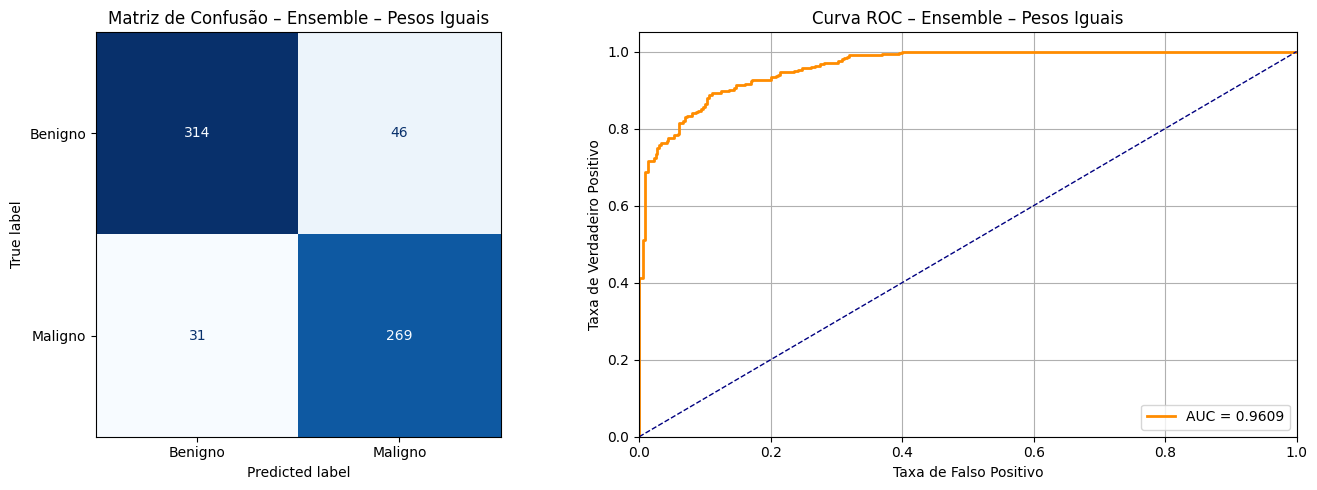


=== Métricas – Ensemble – Pesos Otimizados ===
  Acurácia:       88.33%
  Sensibilidade:  89.67%
  Especificidade: 87.22%
  Precisão:       85.40%
  F1-Score:       87.48%


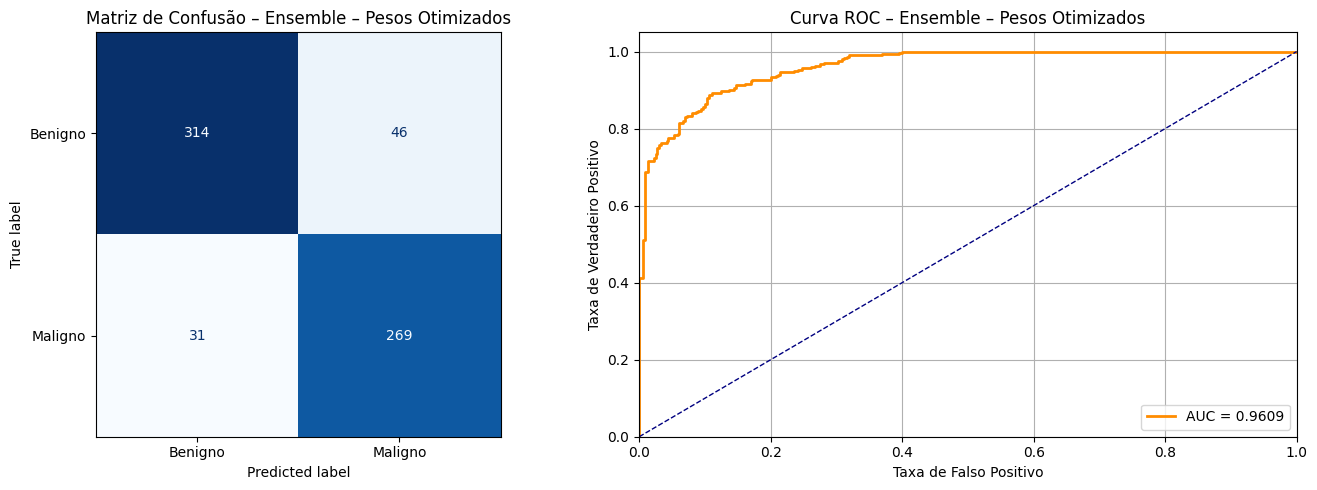

In [24]:
# ── Probabilidades no conjunto de TESTE ──────────────────────────────────────
print('Calculando probabilidades de teste...')
y_test_prob_xception = model_xception.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_test_prob_effnet   = model_effnet.predict(X_test,   batch_size=BATCH_SIZE, verbose=0)
y_test_prob_vit      = model_vit.predict(X_test,      batch_size=BATCH_SIZE, verbose=0)

test_probs = [y_test_prob_xception, y_test_prob_effnet, y_test_prob_vit]

# ── Ensemble com pesos iguais ─────────────────────────────────────────────────
y_prob_ens_equal = ensemble_predict(test_probs, [1/3, 1/3, 1/3])
y_pred_ens_equal = np.argmax(y_prob_ens_equal, axis=1)

resultados['Ensemble_Iguais'] = compute_metrics(
    y_test, y_pred_ens_equal, y_prob_ens_equal, label='Ensemble – Pesos Iguais'
)

# ── Ensemble com pesos otimizados ────────────────────────────────────────────
y_prob_ens_opt = ensemble_predict(test_probs, opt_weights)
y_pred_ens_opt = np.argmax(y_prob_ens_opt, axis=1)

resultados['Ensemble_Otimizado'] = compute_metrics(
    y_test, y_pred_ens_opt, y_prob_ens_opt, label='Ensemble – Pesos Otimizados'
)

## 9. XAI – IA Explicável

Implementamos três técnicas de explicabilidade:

| Técnica | Modelo | Descrição |
|---------|--------|-----------|
| **Grad-CAM** | Xception | Gradientes da última camada conv → mapa de ativação |
| **LIME** | Ensemble | Perturbação de superpixels → importância local |
| **Occlusion Sensitivity** | Ensemble | Janela deslizante → queda na confiança |

Grad-CAM é aplicado sobre o Xception (único backbone CNN do ensemble),  
LIME e Occlusion usam a predição do ensemble completo.

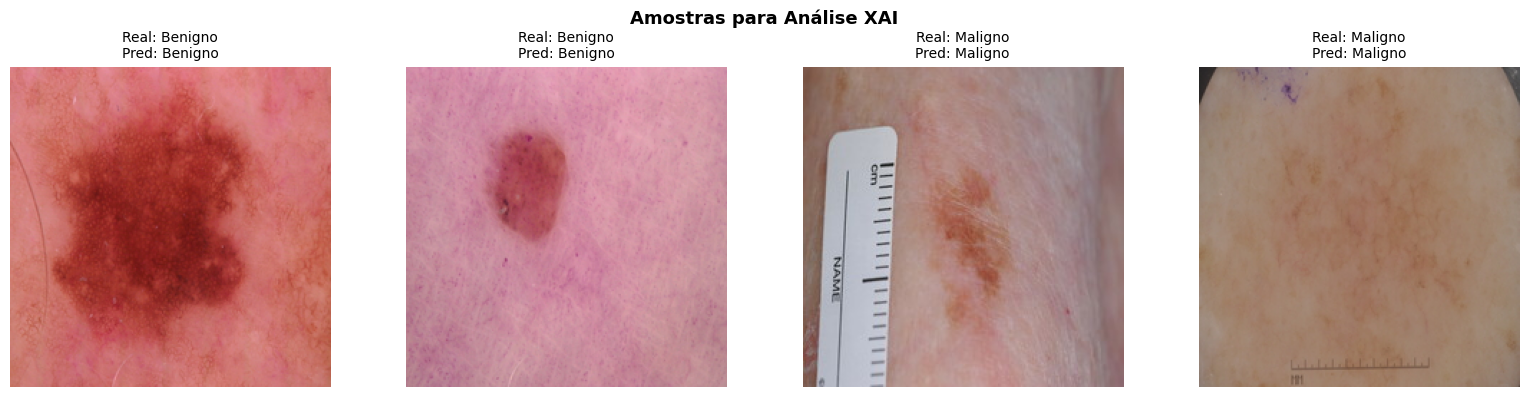

Índices selecionados: [224, 42, 563, 626]


In [25]:
# ── Seleção de 4 imagens para análise XAI (2 benignas + 2 malignas) ──────────
df_test_reset = df_test.reset_index(drop=True)
idx_benign    = df_test_reset[df_test_reset['label'] == 'benign'].sample(2, random_state=SEED).index.tolist()
idx_malignant = df_test_reset[df_test_reset['label'] == 'malignant'].sample(2, random_state=SEED).index.tolist()
idx_xai       = idx_benign + idx_malignant

imgs_xai   = X_test[idx_xai]
labels_xai = ['Benigno', 'Benigno', 'Maligno', 'Maligno']

# Predições do ensemble otimizado sobre as amostras
probs_xai_ens = ensemble_predict(
    [y_test_prob_xception[idx_xai], y_test_prob_effnet[idx_xai], y_test_prob_vit[idx_xai]],
    opt_weights
)
classes_pred_xai = np.argmax(probs_xai_ens, axis=1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, lbl, pred in zip(axes, imgs_xai, labels_xai, classes_pred_xai):
    pred_label = 'Maligno' if pred == 1 else 'Benigno'
    ax.imshow(img)
    ax.set_title(f'Real: {lbl}\nPred: {pred_label}', fontsize=10)
    ax.axis('off')
plt.suptitle('Amostras para Análise XAI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Índices selecionados: {idx_xai}')

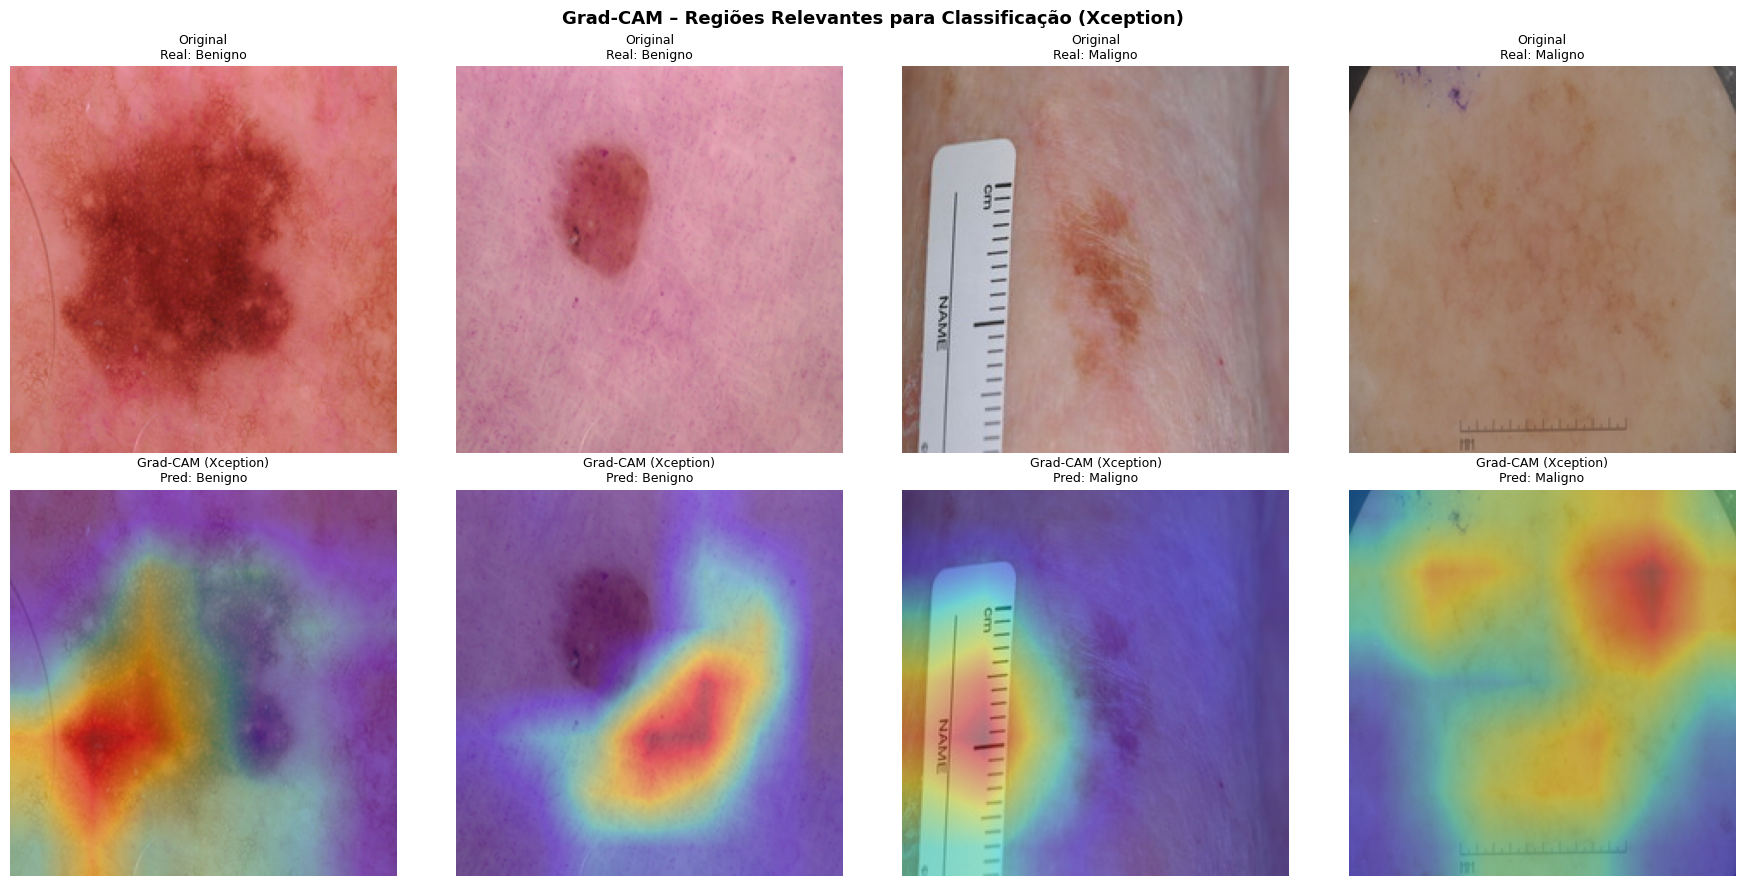

In [26]:
# ── Grad-CAM sobre o Xception ─────────────────────────────────────────────────
# Implementação manual via tf.GradientTape (compatível com Keras 3)
# Gradientes da pontuação da classe predita em relação ao feature map 7×7×2048

def grad_cam_xception(model, img_array, class_idx):
    """
    Calcula heatmap Grad-CAM para o modelo Xception.
    Retorna mapa 2D normalizado [0,1] com shape (224, 224).
    """
    base    = model.layers[1]   # backbone Xception
    img_t   = tf.cast(img_array[np.newaxis, ...], tf.float32)

    with tf.GradientTape() as tape:
        conv_out = base(img_t, training=False)          # (1, 7, 7, 2048)
        tape.watch(conv_out)
        # Aplicar manualmente as camadas densas
        x   = model.layers[2](conv_out)                 # GlobalAveragePooling2D
        x   = model.layers[3](x)                        # Dense(512, relu)
        x   = model.layers[4](x)                        # Dense(256, relu)
        out = model.layers[5](x)                        # Dense(2, softmax)
        score = out[:, class_idx]

    grads       = tape.gradient(score, conv_out)        # (1, 7, 7, 2048)
    pooled_grad = tf.reduce_mean(grads, axis=(0, 1, 2)) # (2048,)

    conv_np   = conv_out[0].numpy()                      # (7, 7, 2048)
    heatmap   = np.einsum('ijk,k->ij', conv_np, pooled_grad.numpy())  # (7, 7)
    heatmap   = np.maximum(heatmap, 0)
    heatmap  /= (heatmap.max() + 1e-8)

    return np.array(Image.fromarray(heatmap).resize((224, 224), Image.BILINEAR))


# ── Visualização Grad-CAM ─────────────────────────────────────────────────────
preds_xception_xai = model_xception.predict(imgs_xai, verbose=0)
classes_xcep_xai   = np.argmax(preds_xception_xai, axis=1)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_xcep_xai)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'
    heatmap    = grad_cam_xception(model_xception, img, int(pred_cls))

    overlay      = cm.jet(heatmap)[..., :3]
    superimposed = np.clip(img * 0.6 + overlay * 0.4, 0, 1)

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\nReal: {lbl}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(superimposed)
    axes[1, i].set_title(f'Grad-CAM (Xception)\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM – Regiões Relevantes para Classificação (Xception)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

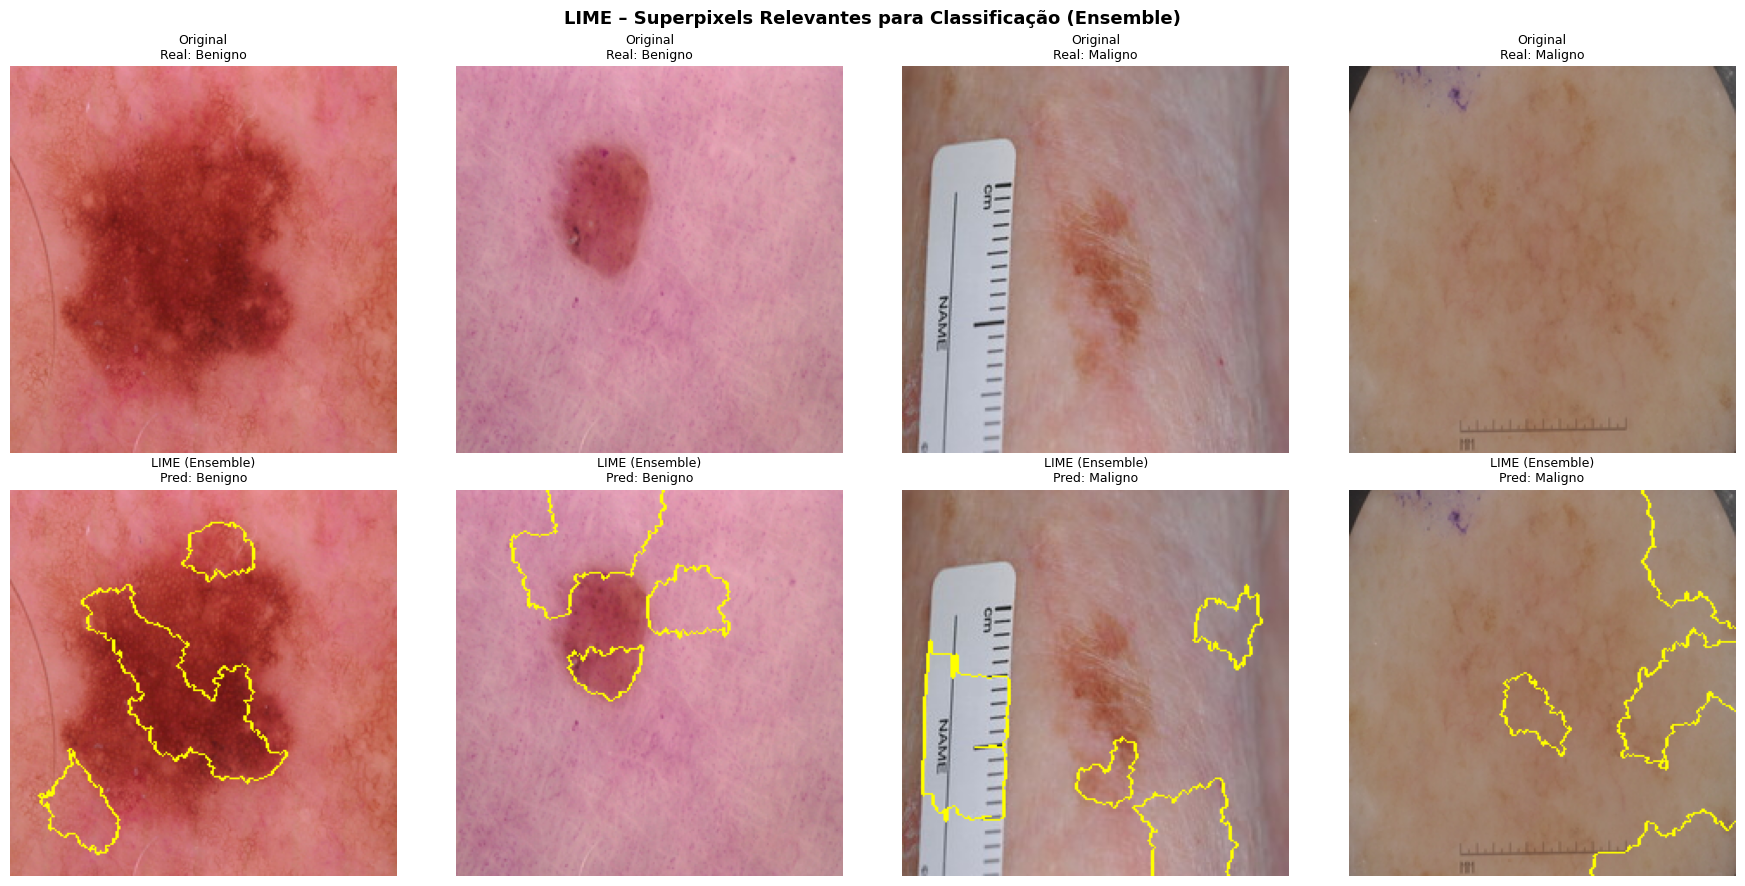

In [27]:
# ── LIME sobre o Ensemble ─────────────────────────────────────────────────────
# Função de predição do ensemble para o LIME
def predict_fn_ensemble(images):
    imgs = np.array(images, dtype=np.float32)
    p1 = model_xception.predict(imgs, verbose=0)
    p2 = model_effnet.predict(imgs, verbose=0)
    p3 = model_vit.predict(imgs, verbose=0)
    return ensemble_predict([p1, p2, p3], opt_weights)

explainer_lime = lime_image.LimeImageExplainer(random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_pred_xai)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'

    explanation = explainer_lime.explain_instance(
        img,
        predict_fn_ensemble,
        top_labels=2,
        hide_color=0,
        num_samples=300
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\nReal: {lbl}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(mark_boundaries(temp, mask))
    axes[1, i].set_title(f'LIME (Ensemble)\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('LIME – Superpixels Relevantes para Classificação (Ensemble)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Calculando Occlusion Sensitivity (pode levar alguns minutos)...


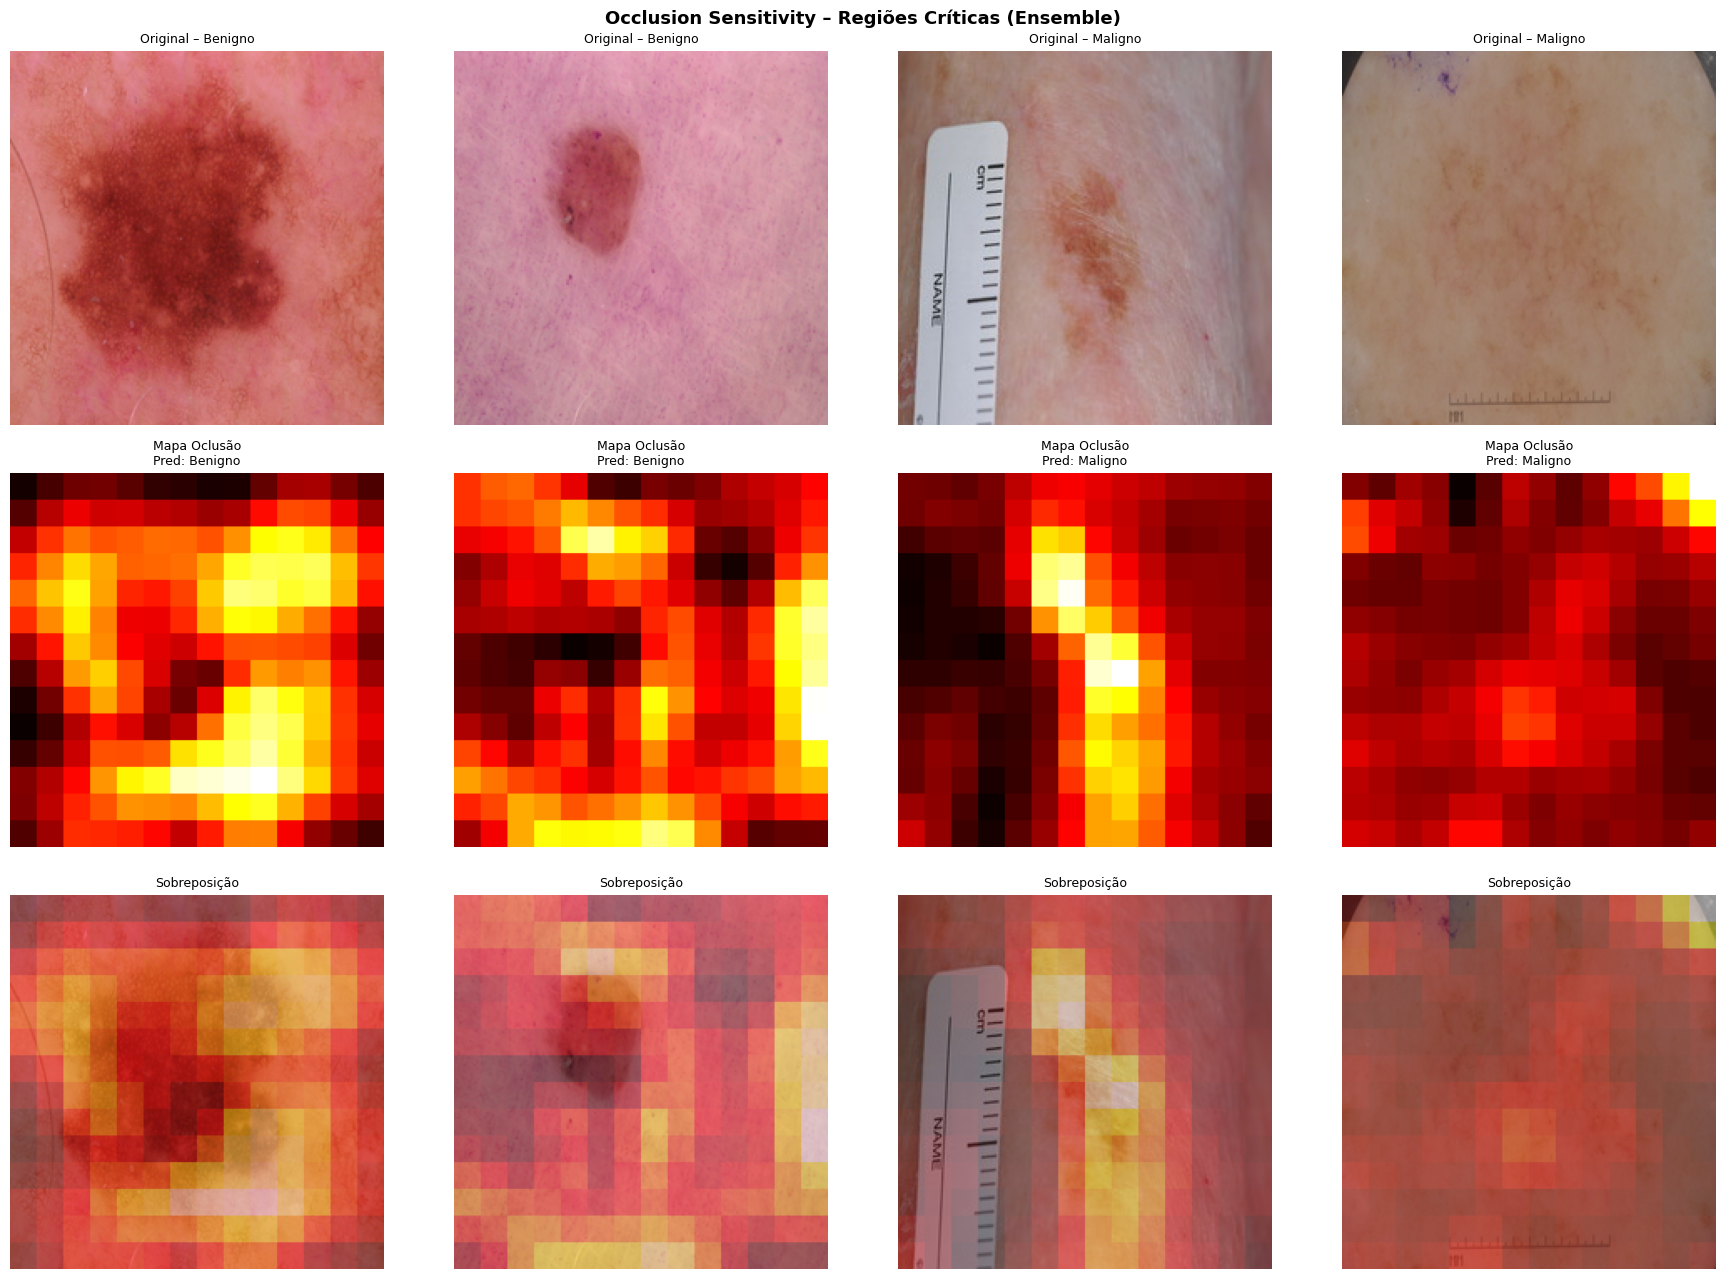

In [28]:
# ── Occlusion Sensitivity sobre o Ensemble ────────────────────────────────────
def occlusion_sensitivity_ensemble(imgs_batch, target_classes, patch_size=32, stride=16):
    """
    Calcula mapas de oclusão para um batch de imagens usando o ensemble.
    Mascara cada patch com cinza (0.5) e mede a queda na confiança.
    """
    H, W = imgs_batch[0].shape[:2]
    sens_maps = []

    for img, target_cls in zip(imgs_batch, target_classes):
        # Confiança base (sem oclusão)
        p1 = model_xception.predict(img[np.newaxis], verbose=0)
        p2 = model_effnet.predict(img[np.newaxis],   verbose=0)
        p3 = model_vit.predict(img[np.newaxis],      verbose=0)
        base_conf = ensemble_predict([p1, p2, p3], opt_weights)[0][target_cls]

        sens_map  = np.zeros((H, W), dtype=np.float32)
        count_map = np.zeros((H, W), dtype=np.float32)

        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                img_occ = img.copy()
                img_occ[y:y+patch_size, x:x+patch_size, :] = 0.5

                p1o = model_xception.predict(img_occ[np.newaxis], verbose=0)
                p2o = model_effnet.predict(img_occ[np.newaxis],   verbose=0)
                p3o = model_vit.predict(img_occ[np.newaxis],      verbose=0)
                conf_occ = ensemble_predict([p1o, p2o, p3o], opt_weights)[0][target_cls]

                drop = base_conf - conf_occ
                sens_map[y:y+patch_size, x:x+patch_size]  += drop
                count_map[y:y+patch_size, x:x+patch_size] += 1

        count_map[count_map == 0] = 1
        sens_maps.append(sens_map / count_map)

    return sens_maps


print('Calculando Occlusion Sensitivity (pode levar alguns minutos)...')
occ_maps = occlusion_sensitivity_ensemble(imgs_xai, classes_pred_xai.tolist())

fig, axes = plt.subplots(3, 4, figsize=(18, 13))

for i, (img, lbl, pred_cls, occ_map) in enumerate(zip(imgs_xai, labels_xai, classes_pred_xai, occ_maps)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'
    occ_norm   = (occ_map - occ_map.min()) / (occ_map.max() - occ_map.min() + 1e-8)
    overlay    = img * 0.6 + plt.cm.hot(occ_norm)[..., :3] * 0.4

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original – {lbl}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(occ_map, cmap='hot')
    axes[1, i].set_title(f'Mapa Oclusão\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

    axes[2, i].imshow(np.clip(overlay, 0, 1))
    axes[2, i].set_title('Sobreposição', fontsize=9)
    axes[2, i].axis('off')

plt.suptitle('Occlusion Sensitivity – Regiões Críticas (Ensemble)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Resumo Final dos Resultados

Comparação completa: três modelos individuais + dois ensembles (pesos iguais e otimizados).

In [29]:
# ── Tabela comparativa completa ───────────────────────────────────────────────
rows_final = []
for key, res in resultados.items():
    rows_final.append({
        'Modelo/Método':     res['label'],
        'Acurácia (%)':      round(res['acuracia'] * 100, 2),
        'Sensibilidade (%)': round(res['sensibilidade'] * 100, 2),
        'Especif. (%)':      round(res['especificidade'] * 100, 2),
        'Precisão (%)':      round(res['precisao'] * 100, 2),
        'F1-Score (%)':      round(res['f1'] * 100, 2),
        'AUC':               round(res['auc'], 4),
    })

df_final = pd.DataFrame(rows_final)
df_final = df_final.sort_values('Acurácia (%)', ascending=False)

print('=== RESUMO FINAL – TODOS OS MODELOS E ENSEMBLES ===')
print(df_final.to_string(index=False))

=== RESUMO FINAL – TODOS OS MODELOS E ENSEMBLES ===
              Modelo/Método  Acurácia (%)  Sensibilidade (%)  Especif. (%)  Precisão (%)  F1-Score (%)    AUC
Ensemble – Pesos Otimizados         88.33              89.67         87.22         85.40         87.48 0.9609
    Ensemble – Pesos Iguais         88.33              89.67         87.22         85.40         87.48 0.9609
                 ViT-B16 TL         88.03              91.33         85.28         83.79         87.40 0.9594
        EfficientNetV2B0 TL         87.42              84.33         90.00         87.54         85.91 0.9474
                Xception TL         82.27              84.33         80.56         78.33         81.22 0.9191


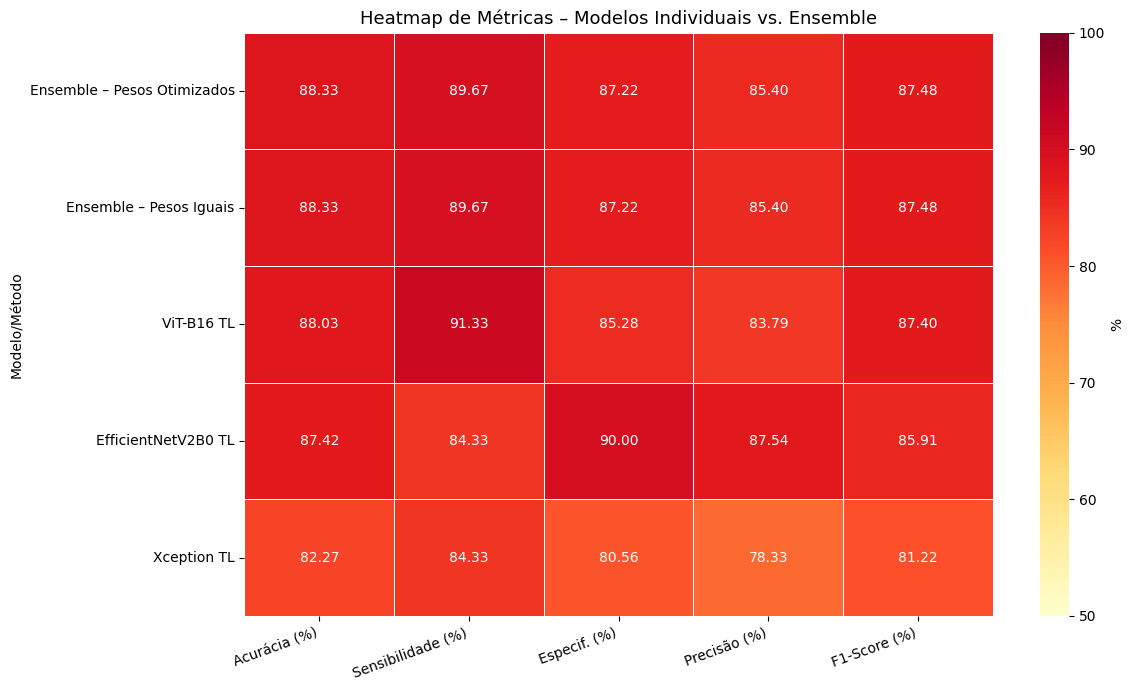

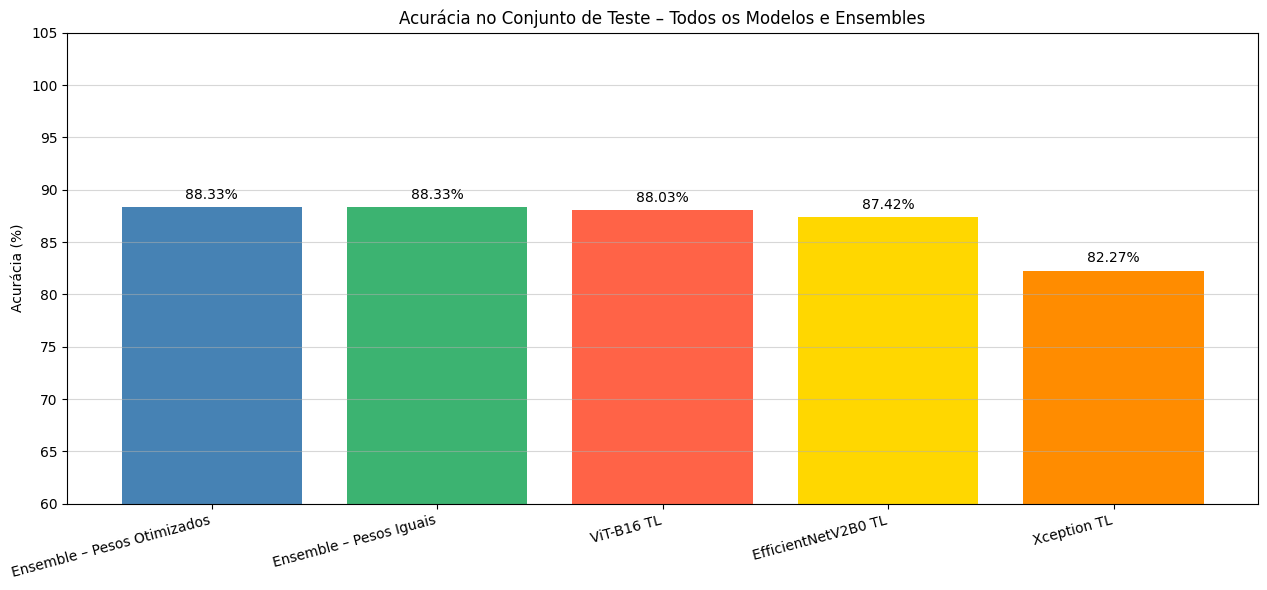

In [30]:
# ── Heatmap de métricas ───────────────────────────────────────────────────────
metricas_heat = df_final.set_index('Modelo/Método')[[
    'Acurácia (%)', 'Sensibilidade (%)', 'Especif. (%)', 'Precisão (%)', 'F1-Score (%)'
]]

plt.figure(figsize=(12, 7))
sns.heatmap(
    metricas_heat,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': '%'},
    vmin=50, vmax=100
)
plt.title('Heatmap de Métricas – Modelos Individuais vs. Ensemble', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ── Gráfico de barras: acurácia de todos ──────────────────────────────────────
plt.figure(figsize=(13, 6))
cores_bar = ['steelblue', 'mediumseagreen', 'tomato', 'gold', 'darkorange']
bars = plt.bar(
    df_final['Modelo/Método'],
    df_final['Acurácia (%)'],
    color=cores_bar[:len(df_final)]
)
plt.ylabel('Acurácia (%)')
plt.title('Acurácia no Conjunto de Teste – Todos os Modelos e Ensembles')
plt.ylim([60, 105])
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=15, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [31]:
# ── Relatório dos pesos otimizados ────────────────────────────────────────────
print('=== PESOS OTIMIZADOS DO ENSEMBLE ===')
print(f'Xception:         {opt_weights[0]:.4f} ({opt_weights[0]*100:.1f}%)')
print(f'EfficientNetV2B0: {opt_weights[1]:.4f} ({opt_weights[1]*100:.1f}%)')
print(f'ViT-B16:          {opt_weights[2]:.4f} ({opt_weights[2]*100:.1f}%)')
print()
print('=== GANHO DO ENSEMBLE SOBRE O MELHOR MODELO INDIVIDUAL ===')
accs_individuais = {k: v['acuracia'] for k, v in resultados.items()
                    if k in ['Xception', 'EfficientNetV2B0', 'ViT-B16']}
melhor_ind = max(accs_individuais, key=accs_individuais.get)
acc_melhor = accs_individuais[melhor_ind]
acc_ens_opt = resultados['Ensemble_Otimizado']['acuracia']
ganho = (acc_ens_opt - acc_melhor) * 100
print(f'Melhor individual: {melhor_ind} – {acc_melhor*100:.2f}%')
print(f'Ensemble otimizado: {acc_ens_opt*100:.2f}%')
print(f'Ganho: {ganho:+.2f} p.p.')

=== PESOS OTIMIZADOS DO ENSEMBLE ===
Xception:         0.3333 (33.3%)
EfficientNetV2B0: 0.3333 (33.3%)
ViT-B16:          0.3333 (33.3%)

=== GANHO DO ENSEMBLE SOBRE O MELHOR MODELO INDIVIDUAL ===
Melhor individual: ViT-B16 – 88.03%
Ensemble otimizado: 88.33%
Ganho: +0.30 p.p.


## 11. Conclusão

Este notebook implementou um **ensemble de Xception + EfficientNetV2B0 + ViT-B16**
com **Weighted Averaging** para classificação binária de lesões cutâneas (ISIC 2018).

### Decisões de Design

| Aspecto | Escolha | Justificativa |
|---------|---------|---------------|
| **Backbone congelado** | 100% frozen | Evitar overfitting com dataset pequeno; extração de features ImageNet |
| **Augmentação** | Rotação + Blur + Sharpen (4×) | Replicação fiel do artigo base (Shah et al. 2024) |
| **Combinação** | Weighted Averaging | Simples, interpretável, sem parâmetros extras |
| **Otimização dos pesos** | SLSQP no val set | Maximiza acurácia sem contaminar o teste |
| **XAI** | Grad-CAM + LIME + Occlusion | Cobre gradientes, perturbação e oclusão |

### Limitações
- Custo computacional elevado: 3 modelos grandes, LIME e Occlusion sobre ensemble
- `vit_keras` pode ter incompatibilidades com Keras 3 (ver nota na Seção 6)
- Pesos SLSQP podem ser instáveis com modelos próximos em desempenho; alternativa: grid search

### Próximos Passos
- Fine-tuning das últimas camadas do backbone (unfreeze parcial)
- Stacking meta-learner em vez de weighted averaging
- Análise de attention maps do ViT como técnica XAI adicional